# Order Book Reconstruction from NASDAQ ITCH Messages

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Reconstruct the **limit order book (LOB)** for a single symbol-day from NASDAQ
ITCH message-by-order (MBO) data, producing a one-second-resolution top-of-book
snapshot series (best bid/ask price and size) with per-second order-flow
imbalance (OFI). The reconstruction tracks full per-order book state internally;
the emitted snapshots record the best bid and ask.

## Learning Objectives

After completing this notebook, you will be able to:
- Process ITCH `A`/`F`/`D`/`X`/`E`/`C`/`U` messages into book state with correct
  handling of Replace (`U`) chains and order-pool tracking.
- Validate reconstruction quality via spread positivity (>99% non-crossed).
- Generate per-second OFI as the building block for short-horizon flow signals.
- Choose between order-by-order tracking and price-level aggregation, and
  understand the trade-offs.

## Book reference

Section §3.3, *From Raw Messages to the Limit Order Book*.

## Prerequisites

- Parsed ITCH message parquets at `data/equities/market/microstructure/nasdaq_itch/messages/`
  (output of `01_itch_parser` or the Rust parser).
- Familiarity with §3.2 (data feed taxonomy) and §3.3 (LOB reconstruction
  algorithm).

**Output**: per-second LOB snapshots saved to
`output/ch03/nasdaq_itch/order_book/{SYMBOL}/lob_snapshots.parquet`.

## Setup

In [1]:
"""Order Book Reconstruction from NASDAQ ITCH Messages — build limit order book from MBO data."""

import os
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from limit_orderbook import (
    get_stock_locate_mapping,
    load_itch_messages,
    reconstruct_lob_with_ofi,
)

from data.equities.loader import load_nasdaq_itch
from utils.paths import get_output_dir

In [2]:
# Input: Pre-parsed ITCH messages from canonical data location
ITCH_DIR = load_nasdaq_itch(get_base_path=True)

# Output: LOB snapshots organized by symbol
OUTPUT_DIR = get_output_dir(3, "nasdaq_itch") / "order_book"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input messages: {ITCH_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Input messages: data/equities/market/microstructure/nasdaq_itch/messages
Output directory: 03_market_microstructure/output/nasdaq_itch/order_book


In [3]:
# Configuration — Papermill injects overrides for CI
SYMBOL = "AAPL"
TRADING_DATE = "2020-01-30"
START_TIME = "09:30:00"
END_TIME = "16:00:00"
MAX_MESSAGES = 0  # 0 = all messages

In [4]:
# Symbol can be overridden via environment variable for batch processing
SYMBOL = os.environ.get("ITCH_SYMBOL", SYMBOL)

# Normalize MAX_MESSAGES: 0 means no limit
if MAX_MESSAGES == 0:
    MAX_MESSAGES = None

In [5]:
# Validate parsed ITCH data — produced by 01_itch_parser or Rust parser
assert ITCH_DIR.exists(), (
    f"Parsed ITCH data not found at {ITCH_DIR}.\n"
    "Run the ITCH pipeline first:\n"
    "  1. Download: uv run python data/equities/market/microstructure/nasdaq_itch_download.py\n"
    "  2. Parse:    Run 01_itch_parser.py (Section 4) or Rust parser (Section 6)"
)
msg_types = sorted([d.name for d in ITCH_DIR.iterdir() if d.is_dir()])
assert len(msg_types) > 0, f"No message types in {ITCH_DIR} — run 01_itch_parser first"
print(f"Available message types: {msg_types}")

Available message types: ['A', 'C', 'D', 'E', 'F', 'H', 'I', 'J', 'K', 'L', 'P', 'Q', 'R', 'S', 'U', 'V', 'X', 'Y']


## 1. Understanding ITCH Message Types

NASDAQ ITCH 5.0 provides message-by-order (MBO) data with these key types:

| Type | Name | Description |
|------|------|-------------|
| **A** | Add Order | New limit order enters the book |
| **F** | Add Order (MPID) | Same as A, with market participant ID |
| **E** | Order Executed | Partial/full execution |
| **C** | Order Executed w/Price | Execution at different price (hidden orders) |
| **X** | Order Cancel | Partial cancellation |
| **D** | Order Delete | Full removal from book |
| **U** | Order Replace | Modify price/size (cancel + add) |
| **P** | Trade | Non-displayed execution |

**Price format**: Integer with 4 implied decimal places (e.g., 3212000 = $321.20)

**Timezone note**: ITCH timestamps are nanoseconds since midnight in US/Eastern (exchange local time).
The data is timezone-naive; convert to America/New_York before cross-source joins.

## 2. Load Messages for Target Symbol

We load all message types needed for LOB reconstruction and **pre-join** them
to attach price and side information to D/X/E messages.

In [6]:
# Get the stock_locate ID for our symbol from R messages
stock_map = get_stock_locate_mapping(ITCH_DIR)
assert SYMBOL in stock_map, f"Symbol {SYMBOL} not found in stock directory"
symbol_locate = stock_map[SYMBOL]
print(f"Symbol {SYMBOL} has stock_locate = {symbol_locate}")

Symbol AAPL has stock_locate = 13


In [7]:
# Add orders (A and F types) - have 'stock' column
add_a = load_itch_messages(ITCH_DIR, "A", symbol=SYMBOL, max_messages=MAX_MESSAGES)
add_f = load_itch_messages(ITCH_DIR, "F", symbol=SYMBOL, max_messages=MAX_MESSAGES)

# Combine A and F (select common columns)
common_cols = [
    "stock_locate",
    "tracking_number",
    "timestamp",
    "order_reference_number",
    "buy_sell_indicator",
    "shares",
    "stock",
    "price",
]
add_orders = pl.concat([add_a.select(common_cols), add_f.select(common_cols)])

# D, X, E, C, U messages don't have 'stock' column - use stock_locate filtering
deletes = load_itch_messages(ITCH_DIR, "D", stock_locate=symbol_locate, max_messages=MAX_MESSAGES)
cancels = load_itch_messages(ITCH_DIR, "X", stock_locate=symbol_locate, max_messages=MAX_MESSAGES)
executions = load_itch_messages(
    ITCH_DIR, "E", stock_locate=symbol_locate, max_messages=MAX_MESSAGES
)
executions_c = load_itch_messages(
    ITCH_DIR, "C", stock_locate=symbol_locate, max_messages=MAX_MESSAGES
)
replaces = load_itch_messages(ITCH_DIR, "U", stock_locate=symbol_locate, max_messages=MAX_MESSAGES)

# P messages (trades) have 'stock' column
trades = load_itch_messages(ITCH_DIR, "P", symbol=SYMBOL, max_messages=MAX_MESSAGES)

In [8]:
# =========================================================================
# CRITICAL: Pre-join D/X/E messages with Add orders to get price and side
# =========================================================================
# This is essential for correct LOB reconstruction. D/X/E messages only have
# order_reference_number - they need to be joined with Add orders to get
# the price and side for each order.

order_cols = ["order_reference_number", "buy_sell_indicator", "price", "shares"]
orders_lookup = add_orders.select(order_cols).rename({"shares": "original_shares"})

# =========================================================================
# IMPORTANT: Do NOT filter D/X/E/C messages based on order lookup!
# =========================================================================
# Orders can be created by U (Replace) messages, not just A/F. The chain:
#   A → U → U → E → D
# means E and D reference an order created by U, which isn't in orders_lookup.
# We look up order info from submitted_orders during reconstruction anyway.
# The join here is ONLY for backward compatibility with code that expects
# these columns - but we DON'T filter based on join results.
#
# Note: The original pre-join approach assumed all orders start with A/F,
# which is wrong for ~95% of replace chains.

In [9]:
# Join D messages (but DON'T filter - order may be from U chain)
if len(deletes) > 0:
    deletes = deletes.join(
        orders_lookup,
        on="order_reference_number",
        how="left",
    )
    # NOT filtered - order info looked up from pool during reconstruction

# Join X messages (but DON'T filter)
if len(cancels) > 0:
    cancels = cancels.join(
        orders_lookup,
        on="order_reference_number",
        how="left",
    )
    # NOT filtered

# Join E messages (but DON'T filter)
if len(executions) > 0:
    executions = executions.join(
        orders_lookup,
        on="order_reference_number",
        how="left",
    )
    # NOT filtered

In [10]:
# Join C messages (but DON'T filter)
if executions_c is not None and len(executions_c) > 0:
    executions_c = executions_c.join(
        orders_lookup,
        on="order_reference_number",
        how="left",
    )
    # NOT filtered

# U (Replace) messages: DON'T filter on join!
# Replace chains can be: A → U → U → U (order created by U, then replaced again)
# The original_order_reference_number may reference an order created by a previous U,
# not an A/F add. We look up the original order from the pool during reconstruction.
if replaces is not None and len(replaces) > 0:
    # Join to get original_side for orders that started with A/F
    replaces = replaces.join(
        orders_lookup.rename(
            {
                "order_reference_number": "original_order_reference_number",
                "price": "original_price",
                "buy_sell_indicator": "original_side",
                "original_shares": "replaced_shares",
            }
        ),
        on="original_order_reference_number",
        how="left",
    )
    # Note: Do NOT filter on original_price.is_not_null() - many U messages
    # reference orders created by other U messages, not A/F. The side is
    # looked up from the order pool during reconstruction.

In [11]:
print(f"\nSymbol: {SYMBOL}")
print(f"Trading Date: {TRADING_DATE}")
print("\nMessage counts:")
print(f"  Add orders (A+F): {len(add_orders):,}")
print(f"  Deletes (D): {len(deletes):,}")
print(f"  Cancels (X): {len(cancels):,}")
print(f"  Executions (E): {len(executions):,}")
print(f"  Replaces (U): {len(replaces) if replaces is not None else 0:,}")
print(f"  Trades (P): {len(trades):,}")


Symbol: AAPL
Trading Date: 2020-01-30

Message counts:
  Add orders (A+F): 907,157
  Deletes (D): 869,314
  Cancels (X): 10,161
  Executions (E): 55,168
  Replaces (U): 151,325
  Trades (P): 15,114


Inspect the structure of `Add` messages — `order_reference_number` is the join
key that lets later `D`/`X`/`E` messages locate the price level and side they
affect.

In [12]:
add_orders.head(5)

stock_locate,tracking_number,timestamp,order_reference_number,buy_sell_indicator,shares,stock,price
u16,u16,datetime[ns],u64,str,u32,str,f64
13,0,2020-01-30 04:00:00.667465235,56305,"""S""",300,"""AAPL""",322.4
13,0,2020-01-30 04:00:00.667616639,56313,"""B""",300,"""AAPL""",320.8
13,0,2020-01-30 04:00:00.667737817,56321,"""S""",200,"""AAPL""",321.8
13,0,2020-01-30 04:00:01.549881344,69981,"""S""",11,"""AAPL""",328.1
13,0,2020-01-30 04:00:05.948486169,99893,"""S""",3,"""AAPL""",325.0


In [13]:
print(f"Price range: ${add_orders['price'].min():.2f} - ${add_orders['price'].max():.2f}")

Price range: $0.00 - $199999.99


## 3. Order Book Reconstruction Algorithm

### Why Price-Level Aggregation?

We use **price-level aggregation** rather than order-by-order tracking:

```
book = {
    "B": {price1: total_shares, price2: total_shares, ...},  # Bids
    "S": {price1: total_shares, price2: total_shares, ...},  # Asks
}
```

**Processing rules for each message type**:
- **A/F (Add)**: Add shares to book at price level
- **D (Delete)**: Subtract original order's shares from price level
- **X (Cancel)**: Subtract cancelled shares from price level
- **E (Execute)**: Subtract executed shares from price level
- **U (Replace)**: Subtract original shares at old price, add new shares at new price

This approach is more robust than order-by-order tracking because it doesn't
require tracking individual order IDs through their lifecycle.

**Note**: The `reconstruct_lob_with_ofi` function is imported from `limit_orderbook` to enable
code reuse with `14_itch_bar_sampling` (Lee-Ready trade classification).

## 4. Run Reconstruction

In [14]:
# Use configured time window (defaults to full RTH: 09:30-16:00)
# Note: We load ALL messages from start of day up to end_time because
# delete/execute messages reference orders placed hours earlier in pre-market.
start_time = datetime.strptime(f"{TRADING_DATE} {START_TIME}", "%Y-%m-%d %H:%M:%S")
end_time = datetime.strptime(f"{TRADING_DATE} {END_TIME}", "%Y-%m-%d %H:%M:%S")

# CRITICAL: Include ALL messages from start of day up to end_time
# Delete/Execute messages at 9:31 reference Add orders from 4:00 AM pre-market.
# Without the full message history, we can't track remaining shares correctly.
#
# The order pool is built incrementally:
# - 4:00 AM: Add order 12345, 500 shares
# - 5:00 AM: Execute 200 shares (remaining = 300)
# - 9:31 AM: Delete order 12345 (remove 300 shares, not 500!)
#
# Snapshots are only generated after start_time.
add_all = add_orders.filter(pl.col("timestamp") <= end_time)
del_all = deletes.filter(pl.col("timestamp") <= end_time)
can_all = cancels.filter(pl.col("timestamp") <= end_time)
exec_all = executions.filter(pl.col("timestamp") <= end_time)
exec_c_all = (
    executions_c.filter(pl.col("timestamp") <= end_time) if executions_c is not None else None
)
rep_all = replaces.filter(pl.col("timestamp") <= end_time) if replaces is not None else None

print(f"Messages for LOB reconstruction (up to {end_time.time()}):")
print(f"  Add orders: {len(add_all):,}")
print(f"  Deletes: {len(del_all):,}")
print(f"  Cancels: {len(can_all):,}")
print(f"  Executions (E): {len(exec_all):,}")
print(f"  Executions (C): {len(exec_c_all) if exec_c_all is not None else 0:,}")
print(f"  Replaces: {len(rep_all) if rep_all is not None else 0:,}")

Messages for LOB reconstruction (up to 16:00:00):
  Add orders: 905,927
  Deletes: 838,145
  Cancels: 10,157
  Executions (E): 54,563
  Executions (C): 227
  Replaces: 151,321


In [15]:
# Reconstruct LOB with OFI using Numba-accelerated function
# This computes Order Flow Imbalance during the reconstruction pass:
# OFI = (Bid Adds - Bid Removes) - (Ask Adds - Ask Removes)
lob = reconstruct_lob_with_ofi(
    add_all,
    del_all,
    can_all,
    exec_all,
    executions_c=exec_c_all,
    replaces=rep_all,
    n_levels=5,
    snapshot_freq="1s",
)

# Filter to RTH snapshots only (reconstruction processes all messages from start of day)
if len(lob) > 0:
    lob = lob.filter(pl.col("timestamp") >= start_time)

assert len(lob) > 0, (
    f"LOB reconstruction returned 0 snapshots for {SYMBOL} on {TRADING_DATE}. "
    "Check that the trading date has parsed ITCH messages on disk."
)

Preparing messages for Numba kernel...


Processing 1,960,340 messages with Numba...


Generated 27,430 snapshots


In [16]:
print(f"LOB snapshots: {len(lob):,}")

LOB snapshots: 22,450


In [17]:
lob.head()

timestamp,best_bid,best_ask,mid_price,spread,bid_size_0,ask_size_0,ofi,bid_add,bid_remove,ask_add,ask_remove
datetime[ns],f64,f64,f64,f64,i64,i64,f64,i64,i64,i64,i64
2020-01-30 09:30:00.505473849,320.65,320.7,320.675,0.05,1,15,-2301.0,2450,1300,3651,200
2020-01-30 09:30:01.505673841,320.5,320.63,320.565,0.13,2614,100,3148.0,20294,5648,19572,8074
2020-01-30 09:30:02.507720895,320.22,320.35,320.285,0.13,35,402,-3410.0,13590,7042,15165,5207
2020-01-30 09:30:03.665037326,320.13,320.3,320.215,0.17,375,40,137.0,1731,1975,2337,2718
2020-01-30 09:30:04.685333820,320.13,320.3,320.215,0.17,475,40,1979.0,1180,300,3051,4150


### Spread validity

A correctly reconstructed book has positive spreads almost everywhere — crossed
quotes (`bid > ask`) signal lost messages or order-pool errors.

In [18]:
valid_count = (lob["spread"] > 0).sum()
crossed_count = (lob["spread"] < 0).sum()
print(f"Valid spreads (spread > 0): {valid_count:,} ({valid_count / len(lob) * 100:.1f}%)")
print(f"Crossed quotes (spread < 0): {crossed_count:,} ({crossed_count / len(lob) * 100:.1f}%)")

Valid spreads (spread > 0): 22,450 (100.0%)
Crossed quotes (spread < 0): 0 (0.0%)


### Order Flow Imbalance per second

OFI = (bid adds − bid removes) − (ask adds − ask removes), aggregated to one
second. Cumulative OFI tracks net buying/selling pressure within the trading
day.

In [19]:
lob.select(
    pl.col("ofi").mean().alias("mean"),
    pl.col("ofi").std().alias("std"),
    pl.col("ofi").quantile(0.5).alias("median"),
    pl.col("ofi").min().alias("min"),
    pl.col("ofi").max().alias("max"),
)

mean,std,median,min,max
f64,f64,f64,f64,f64
39.308775,4646.799332,22.0,-99788.0,482860.0


## 5. Visualize Order Book Dynamics

For detailed spread and imbalance analysis over time, see **`03_itch_lob_analysis`**.
This section focuses on market depth which shows the reconstructed book structure.

In [20]:
# Create output directory for symbol
symbol_dir = OUTPUT_DIR / SYMBOL
symbol_dir.mkdir(parents=True, exist_ok=True)

### 5.1 Market Depth

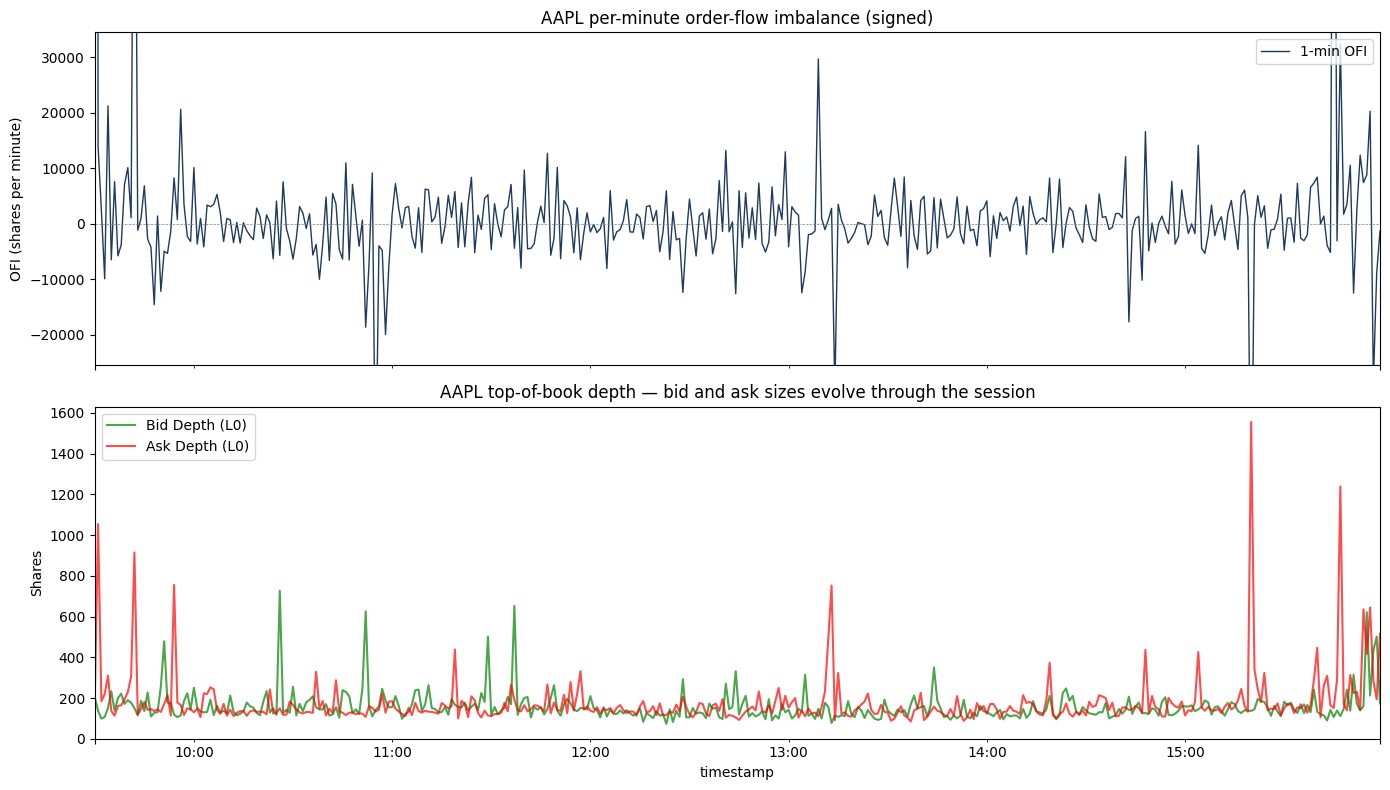

In [21]:
lob_pd = lob.to_pandas().set_index("timestamp")
ofi_1m = (
    lob_pd[["ofi", "bid_size_0", "ask_size_0"]]
    .resample("1min")
    .agg({"ofi": "sum", "bid_size_0": "mean", "ask_size_0": "mean"})
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
# Per-minute OFI (signed). Positive values indicate net buying pressure
# within the minute, negative net selling. Per-minute is more readable
# than the cumulative trace because the opening cross dominates the
# cumulant's scale.
ofi_series = ofi_1m["ofi"].fillna(0)
ofi_series.plot(ax=ax1, color="#1E3A5F", linewidth=1.0, label="1-min OFI")
ax1.axhline(0, color="gray", linestyle="--", linewidth=0.5)
# Y-range from the 1st/99th percentiles to keep extreme minutes from
# squashing the rest of the session.
_vals = ofi_series.to_numpy()
if len(_vals):
    _lo, _hi = np.nanpercentile(_vals, [1, 99])
    _pad = max(abs(_lo), abs(_hi)) * 0.15
    ax1.set_ylim(_lo - _pad, _hi + _pad)
ax1.set_title(f"{SYMBOL} per-minute order-flow imbalance (signed)")
ax1.set_ylabel("OFI (shares per minute)")
ax1.legend(loc="upper right")

ax2 = axes[1]
ofi_1m["bid_size_0"].plot(ax=ax2, label="Bid Depth (L0)", color="green", alpha=0.7)
ofi_1m["ask_size_0"].plot(ax=ax2, label="Ask Depth (L0)", color="red", alpha=0.7)
ax2.set_title(f"{SYMBOL} top-of-book depth — bid and ask sizes evolve through the session")
ax2.set_ylabel("Shares")
ax2.legend()

plt.tight_layout()
plt.show()

For depth imbalance analysis and return predictability, see **`03_itch_lob_analysis`** Section 7.

## 6. Save Results

In [22]:
output_file = symbol_dir / "lob_snapshots.parquet"
lob.write_parquet(output_file)
print(f"Saved LOB snapshots to: {output_file}")
print(f"Shape: {lob.shape}")

Saved LOB snapshots to: 03_market_microstructure/output/nasdaq_itch/order_book/AAPL/lob_snapshots.parquet
Shape: (22450, 12)


## Key Takeaways

### Order Pool Tracking is Essential

**Critical insight**: Proper order book reconstruction requires tracking the
*remaining* shares per order, not just the original order data.

The key challenge is handling message chains correctly:

```
A (Add 500 shares) → E (Execute 100) → E (Execute 200) → D (Delete remaining)
```

After two executions, 200 shares remain. The Delete message must remove 200
shares, not the original 500. This requires maintaining an order pool that
tracks remaining shares after each execution.

### Replace (U) Message Chains

Replace messages create new order references: `A → U → U → U`

When an order is replaced, the *new* order_reference_number becomes canonical.
Subsequent D/E/X messages reference orders created by U, not just A/F adds.
This means ~95% of Replace messages would be lost if we only tracked A/F orders.

### Technical Summary

1. **Order pool tracking**: Track remaining shares per order_reference_number
2. **U creates new orders**: Replace messages spawn new order references
3. **C messages use original price**: Execute-with-price updates book at order's price
4. **P messages don't affect book**: Non-displayable/hidden order executions

### Next Steps

- **`03_itch_lob_analysis`**: Spread dynamics, OFI predictability, liquidity spectrum
- **Chapter 8**: Feature engineering using LOB metrics
- **Chapter 19**: Price impact modeling using depth and imbalance

---

## References

- Bouchaud, J.-P., Bonart, J., Donier, J., & Gould, M. (2018).
  *Trades, Quotes and Prices: Financial Markets Under the Microscope*.
  Cambridge University Press.
  [https://doi.org/10.1017/9781009028943](https://doi.org/10.1017/9781009028943)

- Gould, M. D., Porter, M. A., Williams, S., McDonald, M., Fenn, D. J., & Howison, S. D. (2013).
  "Limit order books." *Quantitative Finance*, 13(11), 1709-1742.
  [https://doi.org/10.1080/14697688.2013.803148](https://doi.org/10.1080/14697688.2013.803148)